# Week 2 Project - Customer Segmentation using RFM Analysis

In [1]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data

In [2]:
df = pd.read_csv("customer_data.csv")

In [3]:
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

# 2. Snapshot Date (one day after last purchase)

In [4]:
snapshot_date = df['PurchaseDate'].max() + dt.timedelta(days=1)

# 3. Calculate RFM Metrics

In [7]:
rfm = df.groupby('CustomerID').agg({
    'PurchaseDate': lambda x: (snapshot_date - x.max()).days,  
    'OrderID': 'count',
    'TransactionAmount': 'sum'                                 
})
rfm.rename(columns={
    'PurchaseDate':'Recency',
    'OrderID':'Frequency',
    'TransactionAmount':'Monetary'
}, inplace=True)

# 4. Assign RFM Scores (1–5 scale using quantiles)

In [8]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)

# 5. Segment Customers

In [9]:
def segment(x):
    if x >= 12: return "Loyal"
    elif x <= 6: return "At Risk"
    else: return "New"
    
rfm['Segment'] = rfm['RFM_Score'].apply(segment)

# 6. Analyze Segments

In [10]:
print(rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}))

           Recency  Frequency    Monetary
Segment                                  
At Risk  47.875000   1.000000  305.119671
Loyal    18.137500   1.287500  889.696125
New      30.175079   1.012618  512.536656


# 7. Visualize Segments

C:\Users\sahuo\AppData\Local\Temp\ipykernel_14632\2665640545.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segment', data=rfm, palette='plasma')


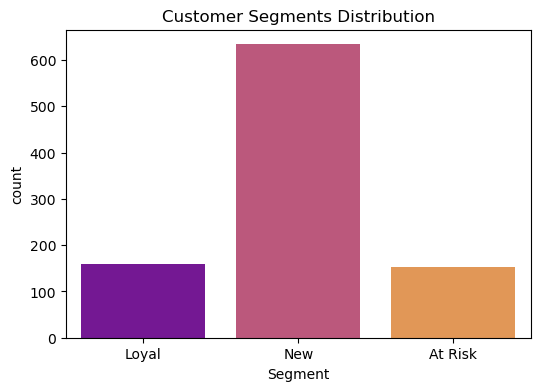

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Segment', data=rfm, palette='plasma')
plt.title("Customer Segments Distribution")
plt.show()

# Optional: Scatter Plot (Recency vs Frequency)

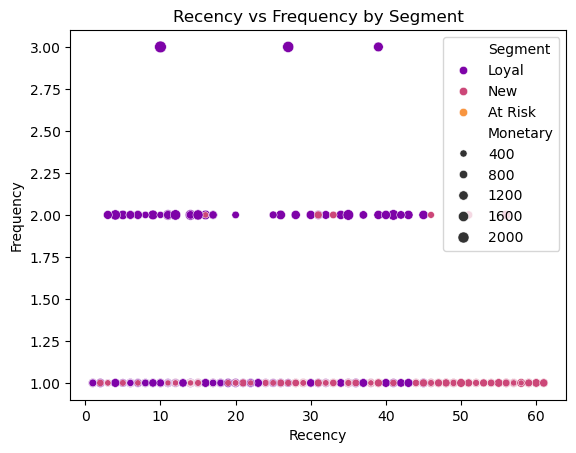

In [12]:
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Segment', size='Monetary', palette='plasma')
plt.title("Recency vs Frequency by Segment")
plt.show()

In [13]:
import plotly.express as px

# 1. Segment Distribution (Pie Chart)


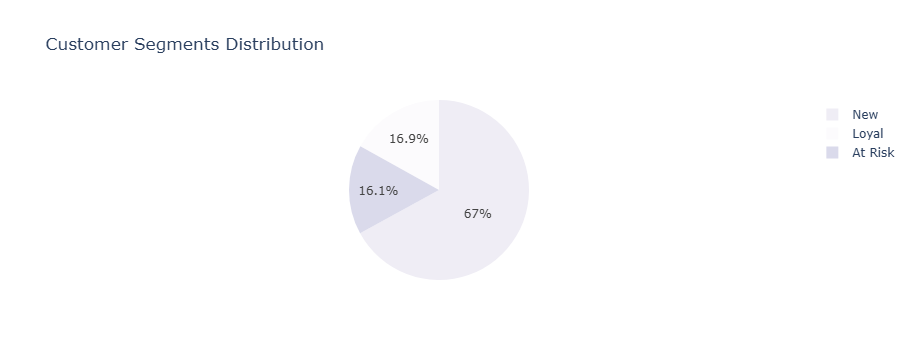

In [14]:
fig = px.pie(rfm, names='Segment', title='Customer Segments Distribution',
             color='Segment', color_discrete_sequence=px.colors.sequential.Purples)
fig.show()

# 2. Average Monetary Value by Segment (Bar Chart)


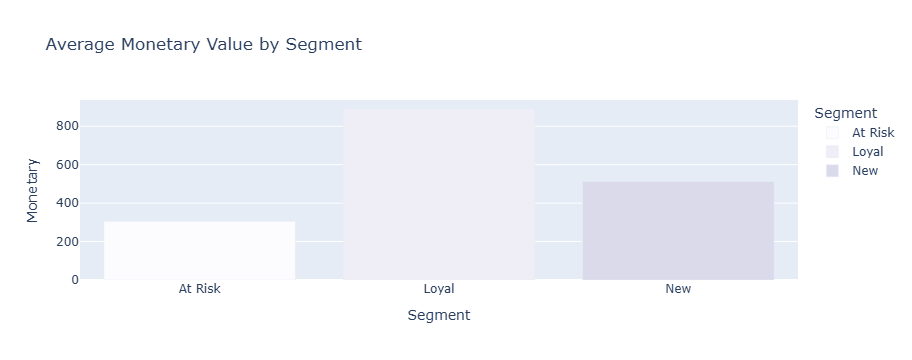

In [15]:
fig = px.bar(rfm.groupby('Segment')['Monetary'].mean().reset_index(),
             x='Segment', y='Monetary', color='Segment',
             title='Average Monetary Value by Segment',
             color_discrete_sequence=px.colors.sequential.Purples)
fig.show()

# 3. Recency vs Frequency Scatter Plot


In [17]:
rfm = rfm.reset_index()


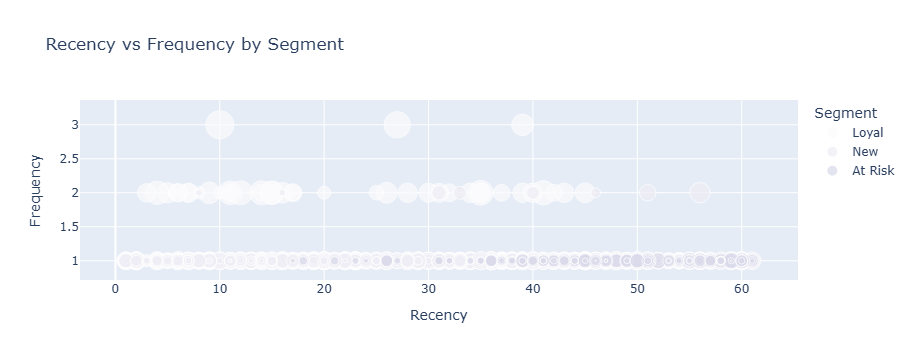

In [18]:
fig = px.scatter(rfm, x='Recency', y='Frequency', color='Segment',
                 size='Monetary', hover_data=['CustomerID'],
                 title='Recency vs Frequency by Segment',
                 color_discrete_sequence=px.colors.sequential.Purples)
fig.show()

# 4. Monetary vs Frequency Bubble Chart


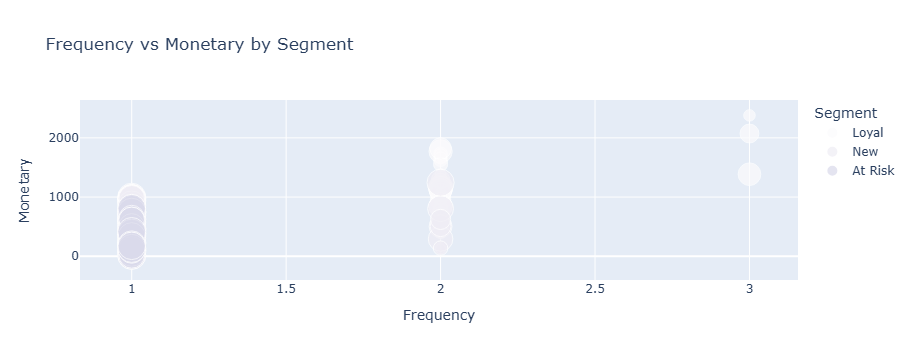

In [19]:
fig = px.scatter(rfm, x='Frequency', y='Monetary', color='Segment',
                 size='Recency', hover_data=['CustomerID'],
                 title='Frequency vs Monetary by Segment',
                 color_discrete_sequence=px.colors.sequential.Purples)
fig.show()

## 📌 Conclusion

The RFM segmentation project successfully demonstrated how transactional data can be transformed into actionable customer insights. By calculating **Recency, Frequency, and Monetary** metrics, we identified distinct customer groups — **Loyal**, **At Risk**, and **New**.  

Interactive visualizations provided a clear understanding of segment distribution and behavior patterns, while targeted marketing recommendations offered practical strategies to engage each group effectively.  

This analysis highlights the importance of data-driven decision making in customer relationship management. With RFM segmentation, businesses can allocate resources more efficiently, personalize campaigns, and ultimately improve customer retention and profitability.  

➡️ In summary, the project delivered a complete workflow: **data preparation → RFM calculation → segmentation → visualization → recommendations**, making it both technically sound and business-ready.
